# Quantamental Workflow Notebook
## DuckDB Exploration → D1/D2/D2R → M01 Feature EDA → Training & Evaluation

**Flow:**
1. DuckDB Basics (read, query, pivot, calc)
2. D1: SEPA Candidates from `v_d1_candidates`
3. D2: Feature enrichment from `daily_features`
4. D2R: Multi-day hydrated trajectories from `v_d2r_hydrated`
5. M01: Feature EDA & Selection
6. M01: Training & Walk-Forward Evaluation

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Project root — adjust if running from different location
PROJECT_ROOT = Path("..").resolve()
DB_PATH = PROJECT_ROOT / "data" / "market_data.duckdb"

assert DB_PATH.exists(), f"DB not found at {DB_PATH}"
print(f"✅ DB: {DB_PATH}  ({DB_PATH.stat().st_size / 1e9:.2f} GB)")


✅ DB: C:\Users\Hang\PycharmProjects\quantamental\data\market_data.duckdb  (3.75 GB)


---
## Section 1: DuckDB Basics
Core patterns: connection, schema inspection, querying, pivoting, window functions.


In [2]:
# Read-only connection (safe for exploration)
con = duckdb.connect(str(DB_PATH), read_only=True)

# List all tables and views
print("=== Tables ===")
con.execute("SHOW TABLES").df()


=== Tables ===


,name
0,buy_list
1,buy_list_activity
2,company_profiles
3,daily_features
4,fundamental_features
5,fundamentals
6,macro_data
7,price_data
8,v_d1_candidates
9,v_d2_features


In [3]:
# Inspect key tables
for table in ["price_data", "daily_features", "company_profiles", "fundamentals"]:
    cols = con.execute(f"PRAGMA table_info('{table}')").df()
    print(f"\n--- {table}: {len(cols)} columns ---")
    print(cols[["name", "type"]].to_string(index=False))



--- price_data: 12 columns ---
      name      type
    ticker   VARCHAR
      date      DATE
      open    DOUBLE
      high    DOUBLE
       low    DOUBLE
     close    DOUBLE
    volume   UBIGINT
 adj_close    DOUBLE
adj_factor    DOUBLE
      vwap    DOUBLE
    source   VARCHAR
updated_at TIMESTAMP

--- daily_features: 109 columns ---
                  name    type
                ticker VARCHAR
                  date    DATE
                 close  DOUBLE
                  open  DOUBLE
                  high  DOUBLE
                   low  DOUBLE
                volume UBIGINT
                sma_20  DOUBLE
                sma_50  DOUBLE
               sma_150  DOUBLE
               sma_200  DOUBLE
         sma_200_lag20  DOUBLE
    close_above_sma200 BOOLEAN
       price_vs_sma_50  DOUBLE
      price_vs_sma_150  DOUBLE
      price_vs_sma_200  DOUBLE
          price_vs_spy  DOUBLE
     price_vs_spy_ma20  DOUBLE
     price_vs_spy_ma50  DOUBLE
     price_vs_spy_ma63  DOUBLE
    pri

In [4]:
# Simple SELECT with date filter
df_price = con.execute("""
    SELECT ticker, date, open, high, low, close, volume
    FROM price_data
    WHERE date >= '2024-01-01'
      AND ticker IN ('AAPL', 'NVDA', 'MSFT', 'TSLA', 'AMZN')
    ORDER BY ticker, date
    LIMIT 100
""").df()

print(f"Shape: {df_price.shape}")
df_price.tail(10)


Shape: (100, 7)


,ticker,date,open,high,low,close,volume
90,AAPL,2024-05-10,184.90,185.09,182.13,183.05,50759500
91,AAPL,2024-05-13,185.44,187.10,184.62,186.28,72044809
92,AAPL,2024-05-14,187.51,188.30,186.29,187.43,52393619
93,AAPL,2024-05-15,187.91,190.65,187.37,189.72,70400000
94,AAPL,2024-05-16,190.47,191.10,189.66,189.84,52845230
95,AAPL,2024-05-17,189.51,190.81,189.18,189.87,41282925
96,AAPL,2024-05-20,189.33,191.92,189.01,191.04,44361300
97,AAPL,2024-05-21,191.09,192.73,190.92,192.35,42309401
98,AAPL,2024-05-22,192.27,192.82,190.27,190.90,34648547
99,AAPL,2024-05-23,190.98,191.00,186.63,186.88,51005924


In [5]:
# Rolling 20-day SMA and volume ratio — computed natively in SQL
df_window = con.execute("""
    SELECT 
        ticker,
        date,
        close,
        AVG(close) OVER (
            PARTITION BY ticker 
            ORDER BY date 
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ) AS sma_20,
        CAST(volume AS BIGINT) AS volume,  -- avoid UBIGINT overflow
        AVG(CAST(volume AS BIGINT)) OVER (
            PARTITION BY ticker 
            ORDER BY date 
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ) AS vol_avg_20,
        CAST(volume AS BIGINT) * 1.0 / NULLIF(
            AVG(CAST(volume AS BIGINT)) OVER (
                PARTITION BY ticker 
                ORDER BY date 
                ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
            ), 0
        ) AS vol_ratio
    FROM price_data
    WHERE ticker = 'NVDA'
      AND date >= '2023-01-01'
    ORDER BY date
    LIMIT 60
""").df()

df_window.tail(10)


,ticker,date,close,sma_20,volume,vol_avg_20,vol_ratio
50,NVDA,2023-03-16,25.54,23.1300,584946260,506439414.5,1.155017
51,NVDA,2023-03-17,25.73,23.3165,848547000,528265450.5,1.606289
52,NVDA,2023-03-20,25.90,23.5420,432747190,526608410.0,0.821763
53,NVDA,2023-03-21,26.20,23.8190,547408000,533478060.0,1.026112
54,NVDA,2023-03-22,26.47,24.1050,797295110,547683599.5,1.455759
55,NVDA,2023-03-23,27.19,24.2815,564889000,520028279.0,1.086266
56,NVDA,2023-03-24,26.78,24.4560,455414070,513313182.5,0.887205
57,NVDA,2023-03-27,26.53,24.6075,361026000,508714782.5,0.709683
58,NVDA,2023-03-28,26.41,24.7670,356104000,503721832.5,0.706946
59,NVDA,2023-03-29,26.98,24.9810,393694000,500405232.5,0.786750


In [6]:
# Pivot: tickers as columns, dates as rows, close as values
df_pivot = con.execute("""
    PIVOT (
        SELECT date, ticker, close
        FROM price_data
        WHERE ticker IN ('AAPL', 'NVDA', 'MSFT', 'TSLA', 'AMZN', 'RKLB', 'SPY')
          AND date >= '2024-01-01'
    )
    ON ticker
    USING LAST(close)
    GROUP BY date
    ORDER BY date
""").df()

df_pivot.set_index('date', inplace=True)
print(f"Shape: {df_pivot.shape}")
df_pivot.tail(5)


Shape: (534, 7)


,AAPL,AMZN,MSFT,NVDA,RKLB,SPY,TSLA
date,,,,,,,
2026-02-11,275.50,204.08,404.37,190.05,69.62,691.96,428.27
2026-02-12,261.73,199.60,401.84,186.94,66.01,681.27,417.07
2026-02-13,255.78,198.79,401.32,182.81,67.44,681.75,417.44
2026-02-17,263.88,201.15,396.86,184.97,69.89,682.85,410.63
2026-02-18,264.35,204.79,399.60,187.98,74.42,686.29,411.32


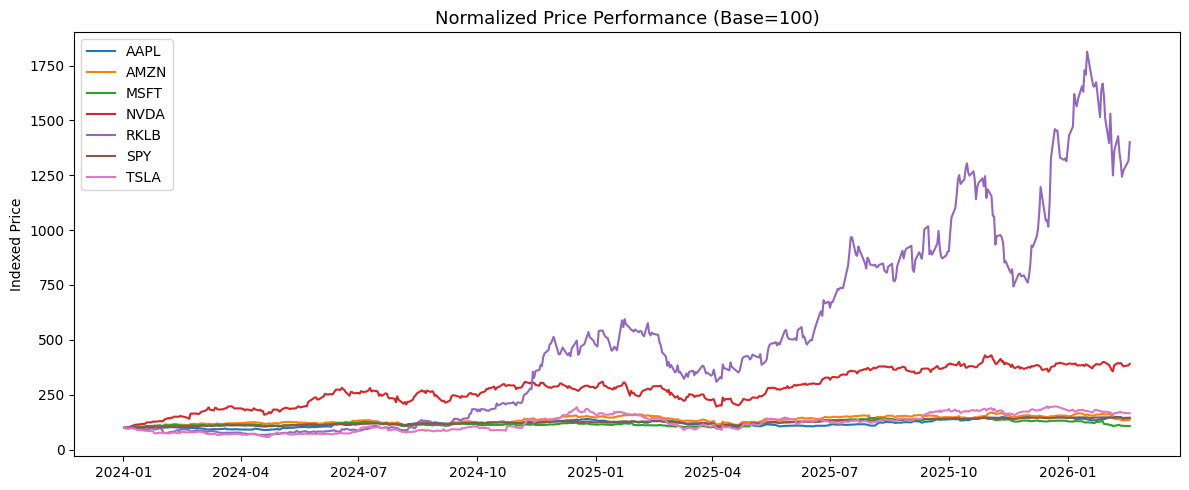

In [7]:
# Normalize to 100 at start
df_norm = df_pivot / df_pivot.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in df_norm.columns:
    ax.plot(df_norm.index, df_norm[col], label=col, linewidth=1.5)

ax.set_title("Normalized Price Performance (Base=100)", fontsize=13)
ax.set_ylabel("Indexed Price")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.show()


In [8]:
# Must pre-compute LAG in a subquery before aggregating
df_breadth = con.execute("""
    WITH lagged AS (
        SELECT
            ticker,
            date,
            close,
            CAST(volume AS BIGINT) AS volume,
            LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
        FROM price_data
        WHERE date >= '2024-01-01'
    )
    SELECT
        date,
        COUNT(*)                                              AS n_stocks,
        SUM(CASE WHEN close > prev_close THEN 1 ELSE 0 END)  AS advancers,
        SUM(CASE WHEN close < prev_close THEN 1 ELSE 0 END)  AS decliners,
        AVG(volume)                                           AS avg_volume,
        MEDIAN(close)                                         AS median_price
    FROM lagged
    GROUP BY date
    ORDER BY date
""").df()

df_breadth['adv_dec_ratio'] = df_breadth['advancers'] / df_breadth['decliners'].clip(1)
df_breadth.tail(10)


,date,n_stocks,advancers,decliners,avg_volume,median_price,adv_dec_ratio
524,2026-02-04,1826,1128.0,690.0,5.488985e+06,59.020,1.634783
525,2026-02-05,1826,584.0,1237.0,5.060390e+06,58.200,0.472110
526,2026-02-06,1826,1538.0,283.0,4.616985e+06,59.395,5.434629
527,2026-02-09,1826,942.0,870.0,4.012933e+06,59.975,1.082759
528,2026-02-10,1826,991.0,819.0,3.968990e+06,59.655,1.210012
529,2026-02-11,1823,815.0,999.0,4.297552e+06,59.630,0.815816
530,2026-02-12,1823,466.0,1347.0,4.975562e+06,58.690,0.345954
531,2026-02-13,1823,1300.0,517.0,4.066715e+06,58.850,2.514507
532,2026-02-17,1823,881.0,926.0,3.736419e+06,58.920,0.951404
533,2026-02-18,1822,1089.0,719.0,3.635903e+06,59.090,1.514604


---
## Section 2: D1 — SEPA Candidates
The `v_d1_candidates` view pre-filters the universe using SEPA criteria:
- Price > $5, Volume > 500K avg, Market Cap > $300M
- SMA(20) > SMA(50), within 25% of 52w high, RS > 0


In [9]:
# Load from pre-computed view
df_d1 = con.execute("""
    SELECT *
    FROM v_d1_candidates
    ORDER BY date DESC, RS_Rating DESC
""").df()

print(f"D1 Shape: {df_d1.shape}")
print(f"Date range: {df_d1['date'].min()} → {df_d1['date'].max()}")
print(f"Unique tickers: {df_d1['ticker'].nunique()}")
df_d1.head()


D1 Shape: (20966, 151)
Date range: 2020-08-06 00:00:00 → 2026-02-18 00:00:00
Unique tickers: 1460


,ticker,date,close,open,high,low,volume,sma_20,sma_50,sma_150,...,low_52w_delta,lowest_low_20d_delta,highest_high_20d_delta,rsi_14_delta,dist_from_52w_high_delta,dist_from_52w_low_delta,dist_from_20d_low_delta,dist_from_20d_high_delta,is_new_trigger,trade_id
0,NESR,2026-02-18,24.67,24.73,25.13,23.87,2309562,20.76000,17.8534,12.751600,...,0.0,0.035477,0.034156,0.091124,-2.421592,0.026357,-0.056317,-2.421592,0,None
1,FSLY,2026-02-18,18.83,17.53,19.02,17.23,16603138,10.86050,10.3846,9.116400,...,0.0,0.000000,0.006792,-0.006848,0.503373,0.041881,0.054860,0.503373,0,None
2,DAN,2026-02-18,34.77,33.58,35.71,33.50,3121681,31.17350,27.1474,22.071867,...,0.0,0.194744,0.125433,-0.041935,-0.098992,0.182167,-0.240660,-0.098992,0,None
3,CC,2026-02-18,21.15,20.76,21.43,20.44,4027477,17.59825,14.8177,14.266100,...,0.0,0.005575,0.036036,0.059939,-8.652174,0.010934,0.001911,-8.652174,0,None
4,ADI,2026-02-18,346.37,352.21,355.36,340.00,8474675,320.13850,298.2916,259.716667,...,0.0,0.030707,0.085699,0.092851,-0.595450,0.148345,0.427196,-0.595450,0,None


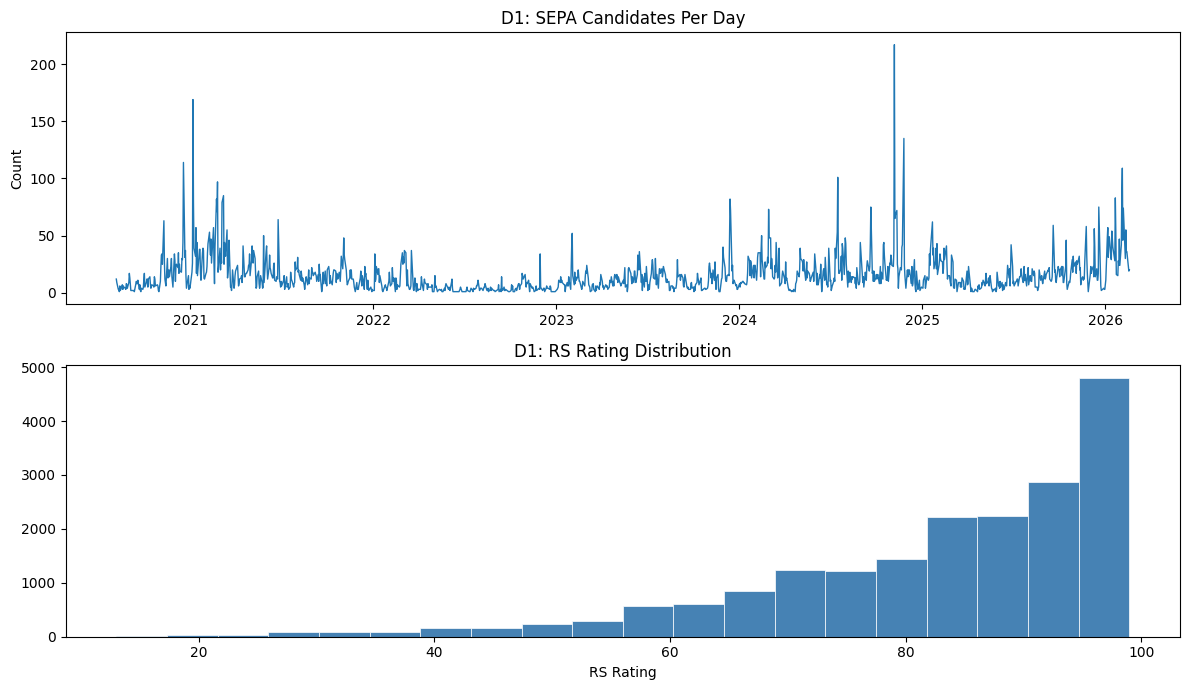


Median candidates/day: 12
       rs_rating     close    vol_avg_20
count   19278.00  20966.00  2.096600e+04
mean       82.59     94.44  5.948629e+06
std        15.17    114.93  2.433249e+07
min        13.00      1.11  5.000228e+05
25%        75.00     26.98  8.980327e+05
50%        87.00     56.18  1.674507e+06
75%        94.00    115.78  3.838300e+06
max        99.00   1684.71  6.805595e+08


In [10]:
# Candidates per day
daily_counts = df_d1.groupby('date').size().reset_index(name='n_candidates')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(daily_counts['date'], daily_counts['n_candidates'], linewidth=1)
axes[0].set_title("D1: SEPA Candidates Per Day")
axes[0].set_ylabel("Count")

# rs_rating is the correct column name (lowercase)
axes[1].hist(df_d1['rs_rating'].dropna(), bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_title("D1: RS Rating Distribution")
axes[1].set_xlabel("RS Rating")

plt.tight_layout()
plt.show()

print(f"\nMedian candidates/day: {daily_counts['n_candidates'].median():.0f}")
# volume_avg_20 may also differ — check actual col name
vol_col = 'volume_avg_20' if 'volume_avg_20' in df_d1.columns else 'vol_avg_20'
print(df_d1[['rs_rating', 'close', vol_col]].describe().round(2))


---
## Section 3: D2 — Feature-Enriched Dataset
`v_d2_features` joins D1 candidates with all computed features from `daily_features`.
This is the input to M01 training.


In [11]:
# D2: candidates joined with their feature snapshot on entry date
df_d2 = con.execute("""
    SELECT *
    FROM v_d2_features
    ORDER BY date DESC
""").df()

print(f"D2 Shape: {df_d2.shape}")
print(f"Columns: {list(df_d2.columns[:20])} ...")
df_d2.head(3)


D2 Shape: (20994, 185)
Columns: ['ticker', 'date', 'close', 'open', 'high', 'low', 'volume', 'sma_20', 'sma_50', 'sma_150', 'sma_200', 'sma_200_lag20', 'close_above_sma200', 'price_vs_sma_50', 'price_vs_sma_150', 'price_vs_sma_200', 'price_vs_spy', 'price_vs_spy_ma20', 'price_vs_spy_ma50', 'price_vs_spy_ma63'] ...


,ticker,date,close,open,high,low,volume,sma_20,sma_50,sma_150,...,gross_margin_trend,fundamental_filing_date,fiscal_period,days_since_report,market_cap,shares_outstanding,pe_ratio,ps_ratio,pb_ratio,peg_adjusted
0,M,2026-02-18,22.77,22.50,23.01,22.02,8432520,21.18900,22.0910,18.555867,...,1.156863,2025-12-03,Q3,77,6.084976e+09,<NA>,569.250000,NaN,NaN,NaN
1,ESI,2026-02-18,33.69,34.29,35.18,32.04,5797439,30.34850,28.1778,26.374800,...,-1.103708,2026-02-18,Q4,0,6.389451e+09,<NA>,1336.904762,NaN,NaN,NaN
2,ATMU,2026-02-18,64.24,64.25,65.54,63.71,1036847,60.24425,56.2209,48.441300,...,NaN,2026-02-13,Q4,5,4.385681e+09,<NA>,110.758621,NaN,NaN,4.833103


In [12]:
# Null coverage
null_pct = (df_d2.isnull().sum() / len(df_d2) * 100).sort_values(ascending=False)
null_pct_significant = null_pct[null_pct > 1]

print(f"Features with >1% nulls: {len(null_pct_significant)}")
print(null_pct_significant.head(20).to_string())

# Numeric summary
df_d2.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].round(3).head(30)


Features with >1% nulls: 78
ps_ratio                     99.876155
pb_ratio                     99.876155
shares_outstanding           99.876155
trade_id                     93.026579
inventory_vs_sales_spread    63.675336
inventory_growth_yoy         63.170430
peg_adjusted                 48.918739
rs_lag1                      14.923311
rs_delta                     14.923311
rs_ma_lag1                   14.923311
rs_ma_delta                  14.923311
rs_velocity                   9.550348
revenue_cagr_3y               8.130895
mom_252d                      8.059446
RS_Sector_Rank                8.059446
RS_Universe_Rank              8.059446
rs_rating                     8.059446
rs                            8.059446
rs_ma                         8.059446
Sector_Momentum               8.059446


,count,mean,std,min,50%,max
date,20994,2023-07-12 23:10:45.098599,NaN,2020-08-06 00:00:00,2023-12-13 00:00:00,2026-02-18 00:00:00
close,20994.0,94.39502,114.885884,1.11,56.16,1684.71
open,20994.0,92.291943,112.762624,1.1,54.795,1642.93
high,20994.0,95.577645,116.229522,1.14,56.95,1693.35
low,20994.0,91.340801,111.63919,1.08,54.15,1608.21
volume,20994.0,10803922.29899,42285189.195515,437300.0,2977460.0,1543911000.0
sma_20,20994.0,85.700316,105.754923,1.0341,50.23525,1461.4395
sma_50,20994.0,82.019172,101.966553,0.8672,47.8407,1305.2782
sma_150,20994.0,73.821025,93.163166,0.687667,42.523967,1103.174933
sma_200,20994.0,70.719388,89.745445,0.644006,40.554216,1024.50885


---
## Section 4: D2R — Hydrated Trajectories
`v_d2r_hydrated` contains multi-day OHLCV trajectories after each candidate entry.
Used to calculate MFE/MAE, label outcomes, and train M02.


In [13]:
# D2R: forward price paths from entry date
df_d2r = con.execute("""
    SELECT *
    FROM v_d2r_hydrated
    ORDER BY entry_date DESC, ticker
    LIMIT 50000
""").df()

print(f"D2R Shape: {df_d2r.shape}")
print(f"Columns: {list(df_d2r.columns)}")
df_d2r.head(5)


D2R Shape: (38173, 13)
Columns: ['trade_id', 'ticker', 'entry_date', 'sepa_exit_date', 'date', 'days_in_trade', 'open', 'high', 'low', 'close', 'volume', 'sma_50', 'atr_20d']


,trade_id,ticker,entry_date,sepa_exit_date,date,days_in_trade,open,high,low,close,volume,sma_50,atr_20d
0,KW_20260217,KW,2026-02-17,2026-06-17,2026-02-17,0,10.83,10.89,10.82,10.86,6899026,9.8363,0.19525
1,KW_20260217,KW,2026-02-17,2026-06-17,2026-02-18,1,10.85,10.95,10.84,10.95,3138300,9.8615,0.19075
2,IPGP_20260212,IPGP,2026-02-12,2026-06-12,2026-02-12,0,116.70,154.21,115.87,150.25,2484400,85.3596,6.68675
3,IPGP_20260212,IPGP,2026-02-12,2026-06-12,2026-02-17,5,150.01,150.10,124.44,134.86,1462663,87.8558,8.64725
4,IPGP_20260212,IPGP,2026-02-12,2026-06-12,2026-02-18,6,134.65,140.26,132.00,138.28,599196,88.9642,8.90525


In [14]:
df_d2r[df_d2r['trade_id'] == 'ZG_20200806'].sort_values('date').head(10)

,trade_id,ticker,entry_date,sepa_exit_date,date,days_in_trade,open,high,low,close,volume,sma_50,atr_20d
38118,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-06,0,70.2800,73.200,70.2500,71.57,1370901,61.9374,3.129570
38152,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-07,1,79.4500,85.160,76.2350,79.84,3805423,62.3900,3.725020
38129,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-10,4,79.7500,80.875,78.4207,79.41,944680,62.8190,3.602155
38170,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-11,5,79.3300,79.550,74.9050,75.24,534790,63.1578,3.689405
38150,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-12,6,75.7600,78.485,75.6000,76.10,388614,63.4934,3.724155
38147,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-13,7,76.7300,77.680,74.0350,74.56,824036,63.7420,3.674095
38123,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-14,8,74.6300,77.030,73.6177,76.67,464208,64.0478,3.715710
38125,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-17,11,77.5400,80.710,77.2600,79.82,478525,64.4538,3.777205
38143,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-18,12,80.4006,82.940,80.0600,82.39,560852,64.8586,3.775705
38172,ZG_20200806,ZG,2020-08-06,2020-10-26,2020-08-19,13,82.3400,84.810,81.0400,83.50,575712,65.3088,3.811705


Outcome rows: 1464
Columns: ['ticker', 'date', 'close', 'open', 'high', 'low', 'volume', 'sma_20', 'sma_50', 'sma_150', 'sma_200', 'sma_200_lag20', 'close_above_sma200', 'price_vs_sma_50', 'price_vs_sma_150', 'price_vs_sma_200', 'price_vs_spy', 'price_vs_spy_ma20', 'price_vs_spy_ma50', 'price_vs_spy_ma63', 'price_vs_spy_ma200', 'rs_line_uptrend', 'rs_line_log', 'rs_line_delta', 'rs_line_lag_delta', 'rs_rating', 'rs', 'rs_ma', 'vol_avg_20', 'vol_avg_50', 'vol_ratio', 'vol_ratio_50', 'vol_ma20', 'vol_ma50', 'dollar_volume_avg_20', 'dry_up_volume', 'turnover', 'turnover_ma20', 'atr_14', 'atr_20d', 'natr', 'volatility_20d', 'vcp_ratio', 'consolidation_width', 'high_52w', 'low_52w', 'highest_high_20d', 'lowest_low_20d', 'high_20d', 'pct_from_high_52w', 'pct_above_low_52w', 'dist_from_52w_high', 'dist_from_52w_low', 'dist_from_20d_low', 'dist_from_20d_high', 'return_1d', 'return_5d', 'return_20d', 'return_60d', 'mom_21d', 'mom_63d', 'mom_126d', 'mom_189d', 'mom_252d', 'rsi_14', 'sma_50_slope

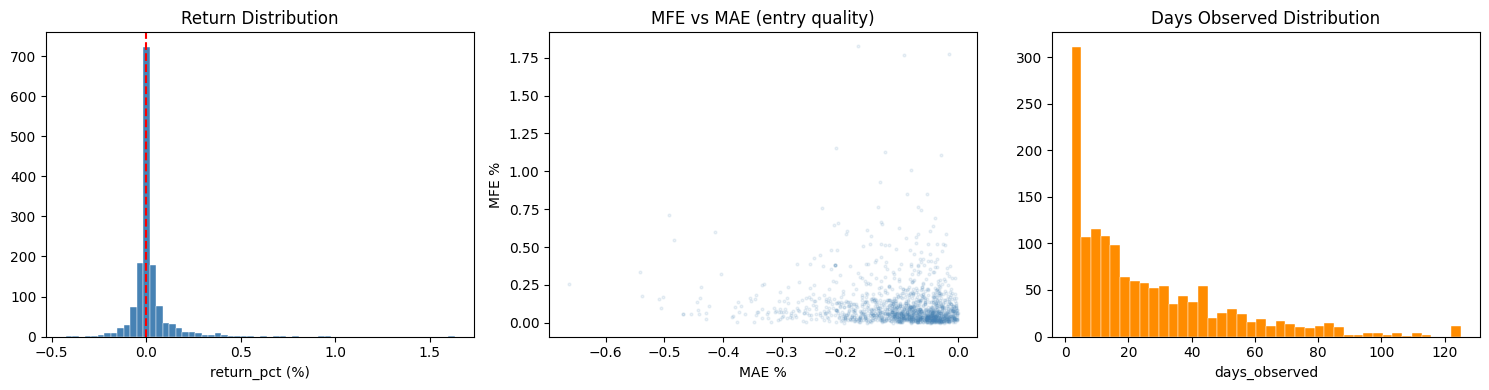

        mae_pct   mfe_pct  return_pct
count  1464.000  1464.000    1464.000
mean     -0.101     0.113       0.017
std       0.087     0.153       0.107
min      -0.663     0.000      -0.426
25%      -0.133     0.033      -0.012
50%      -0.079     0.067       0.000
75%      -0.041     0.133       0.025
max      -0.000     1.826       1.631


In [15]:
# v_d2r_hydrated is raw OHLCV only (trade_id, ticker, entry_date, date, days_in_trade, OHLCV)
# Outcomes are in v_d2_training — load from there instead
df_outcomes = con.execute("""
    SELECT 
        *
    FROM v_d2_training
    WHERE mfe_pct IS NOT NULL
""").df()

print(f"Outcome rows: {len(df_outcomes)}")
print(f"Columns: {list(df_outcomes.columns)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_outcomes['return_pct'].clip(-30, 60), bins=60,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title("Return Distribution")
axes[0].set_xlabel("return_pct (%)")

axes[1].scatter(df_outcomes['mae_pct'].clip(-30, 0),
                df_outcomes['mfe_pct'].clip(0, 80),
                alpha=0.1, s=4, color='steelblue')
axes[1].set_xlabel("MAE %")
axes[1].set_ylabel("MFE %")
axes[1].set_title("MFE vs MAE (entry quality)")

axes[2].hist(df_outcomes['days_observed'].clip(0, 125), bins=40,
             color='darkorange', edgecolor='white', linewidth=0.3)
axes[2].set_title("Days Observed Distribution")
axes[2].set_xlabel("days_observed")

plt.tight_layout()
plt.show()

print(df_outcomes[['mae_pct', 'mfe_pct', 'return_pct']].describe().round(3))


In [16]:
df_outcomes.head()

,ticker,date,close,open,high,low,volume,sma_20,sma_50,sma_150,...,log_current_ratio,log_days_since_report,log_pb_ratio,RSI_14_1,VCP_Ratio_1,Is_Green_Day_1,Price_vs_SMA_50_Delta_1,Price_vs_SMA_150_Delta_1,Dist_From_20D_High_Delta_1,Dist_From_52W_High_Delta_1
0,AAOI,2023-07-10,8.34,7.40,8.37,7.31,4763237,5.08775,3.2162,2.623133,...,0.579766,4.219508,NaN,73.612991,2.381978,1,NaN,NaN,NaN,NaN
1,ALGT,2026-02-04,99.86,94.33,100.46,94.13,1264229,90.04650,85.4594,68.412533,...,NaN,0.000000,NaN,70.871058,1.050991,1,NaN,NaN,NaN,NaN
2,FTV,2023-07-26,57.83,55.93,57.98,55.12,4246400,55.86500,53.1058,50.904133,...,0.671562,0.000000,NaN,79.345955,0.877911,1,NaN,NaN,NaN,NaN
3,FIVE,2020-11-09,146.30,145.46,159.59,145.46,1459973,136.40550,131.2620,110.864467,...,0.939223,4.219508,NaN,63.902439,1.225191,1,NaN,NaN,NaN,NaN
4,GEHC,2024-09-25,93.01,92.79,93.53,92.15,4044715,87.43750,84.6254,83.973667,...,0.700394,4.043051,NaN,72.990354,0.898893,1,NaN,NaN,NaN,NaN


---
## Section 5: M01 Feature EDA & Selection
Analyze feature distributions, correlations, and predictive power against the target.


In [21]:
import sys, numpy as np
sys.path.insert(0, str(PROJECT_ROOT))
from src.view_manager import COLUMN_CASE_MAP
from src.feature_config import M01_FEATURES, LEAKAGE_FEATURES, CATEGORICAL_FEATURES

df_train_raw = con.execute("""
    SELECT *
    FROM v_d2_training
    WHERE mfe_pct IS NOT NULL
""").df()
df_train_raw = df_train_raw.rename(columns=COLUMN_CASE_MAP)
print(f"Raw training set: {df_train_raw.shape}")

# --- Apply log transforms inline (FeaturePreprocessor normally does this) ---
LOG_COLS = [
    'close', 'volume_avg_20', 'dollar_volume_avg_20', 'atr_20',
    'alpha001', 'alpha009', 'alpha060',
    'Price_vs_SMA_50', 'Price_vs_SMA_150', 'Price_vs_SMA_200',
    'Dist_From_52W_High', 'Dist_From_20D_Low',
    'mfe_pct', 'mae_pct',
]
for col in LOG_COLS:
    if col in df_train_raw.columns:
        df_train_raw[f'log_{col}'] = np.sign(df_train_raw[col]) * np.log1p(np.abs(df_train_raw[col]))

# Fix rs_rating to 1-99 percentile
if 'RS_Universe_Rank' in df_train_raw.columns:
    df_train_raw['rs_rating'] = df_train_raw['RS_Universe_Rank'] * 99

# Sector/industry from company_profiles if missing
if 'sector_id' not in df_train_raw.columns and 'sector_1' in df_train_raw.columns:
    df_train_raw['sector_id'] = df_train_raw['sector_1'].astype('category').cat.codes
if 'industry_id' not in df_train_raw.columns and 'industry_1' in df_train_raw.columns:
    df_train_raw['industry_id'] = df_train_raw['industry_1'].astype('category').cat.codes

available = [f for f in M01_FEATURES if f in df_train_raw.columns]
missing   = [f for f in M01_FEATURES if f not in df_train_raw.columns]
print(f"M01 features defined: {len(M01_FEATURES)}")
print(f"Available after inline transforms: {len(available)}")
print(f"Still missing: {len(missing)} — {missing[:10]}")

df_train = df_train_raw.copy()


Raw training set: (1464, 242)
M01 features defined: 73
Available after inline transforms: 73
Still missing: 0 — []


In [25]:
# ── Cell 2: Run Quant-Standard 4-Pillar EDA ──────────────────────────────────
from pathlib import Path
from src.evaluation.feature_screener import FeatureScreener
from src.feature_config import FEATURE_AUTO_EXCLUDE, M03_FEATURES

# ── Config (mirrors WorkflowConfig defaults) ──
EDA_TARGET      = 'return_pct'   # or 'y_max' if you added MFE enrichment
KS_THRESHOLD    = 0.05           # composite threshold (same as --ks-threshold)
CORR_THRESHOLD  = 0.7            # cluster pruning threshold
EXCLUDE_M03     = False          # set True to strip m03_* regime features
OUTPUT_DIR      = Path('../models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Auto-exclusions: stale + (optionally) M03 features
exclusions = set(FEATURE_AUTO_EXCLUDE)
if EXCLUDE_M03:
    exclusions.update(M03_FEATURES)

# Pass None → FeatureScreener auto-discovers all numeric cols, then pre-filters
eda_results = FeatureScreener.run_quant_pipeline(
    df=df_train,
    candidate_features=None,      # auto-discover from v_d2_training columns
    target_col=EDA_TARGET,
    date_col='entry_date',
    ks_threshold=KS_THRESHOLD,
    correlation_threshold=CORR_THRESHOLD,
    winsorize=True,
    encode_categoricals=True
)

passed   = eda_results['passed']
failed   = eda_results['failed_composite']
excluded = eda_results['excluded_raw']
dropped  = eda_results['excluded_correlation']

print(f"\n{'='*60}")
print(f"  EDA COMPLETE")
print(f"{'='*60}")
print(f"  Pre-filtered (raw/excluded): {len(excluded)}")
print(f"  Failed composite threshold:  {len(failed)}")
print(f"  Removed by cluster pruning:  {len(dropped)}")
print(f"  ✅ Passed → selected:        {len(passed)}")
print(f"\nSelected features:\n  {passed}")

INFO:src.evaluation.feature_screener:Pre-filter: 234 candidates -> 232 after removing 2 raw/excluded columns
INFO:src.evaluation.feature_screener:Target encoded sector: 11 categories, global_mean=0.02%, smoothing=10.0
INFO:src.evaluation.feature_screener:Created sector_encoded from sector (11 categories)
INFO:src.evaluation.feature_screener:Target encoded industry: 137 categories, global_mean=0.02%, smoothing=10.0
INFO:src.evaluation.feature_screener:Created industry_encoded from industry (137 categories)
INFO:src.evaluation.feature_screener:Added sector_encoded to feature candidates
INFO:src.evaluation.feature_screener:Added industry_encoded to feature candidates
INFO:src.evaluation.feature_screener:Winsorized close (TAR=0.86<=1.2, kurtosis=11.2)
INFO:src.evaluation.feature_screener:Winsorized open (TAR=0.65<=1.2, kurtosis=11.3)
INFO:src.evaluation.feature_screener:Winsorized high (TAR=0.85<=1.2, kurtosis=11.1)
INFO:src.evaluation.feature_screener:Winsorized low (TAR=0.65<=1.2, kurtos

ValueError: Linkage 'Z' contains negative distances.

In [24]:
# ── Cell 3: Composite scores table ───────────────────────────────────────────
scores = eda_results['composite_scores']
print(scores.sort_values('composite', ascending=False).to_string(index=False))

NameError: name 'eda_results' is not defined

In [19]:
import numpy as np

# Available outcome columns from v_d2_training:
#   return_120d  → M01_A baseline (closest proxy to return_pct)
#   mfe_pct      → used in B, C, D, E targets
#   mae_pct      → used in B, E targets (stop-loss accountability)
# Note: true return_pct (from trade sim exit) is not in DuckDB views

# --- Compute all 5 ablation targets ---

# A: baseline — 120d realized return
df_train['target_A'] = df_train['return_pct']

# B: hybrid_floor — MFE for winners, capped penalty for losers
nATR_col = 'nATR' if 'nATR' in df_train.columns else 'atr_20'
if nATR_col in df_train.columns:
    stop_penalty = np.maximum(-10.0, -2.0 * df_train[nATR_col] * 100)
    df_train['target_B'] = np.where(df_train['mfe_pct'] >= 15,
                                    df_train['mfe_pct'],
                                    stop_penalty)
else:
    df_train['target_B'] = np.where(df_train['mfe_pct'] >= 15,
                                    df_train['mfe_pct'],
                                    np.maximum(-10.0, df_train['mae_pct']))

# C: risk_adjusted — MFE / nATR
if nATR_col in df_train.columns:
    df_train['target_C'] = df_train['mfe_pct'] / (df_train[nATR_col] * 100 + 0.01)
else:
    df_train['target_C'] = df_train['mfe_pct'] / (df_train['atr_20'].clip(0.001) * 100)

# D: log_space — sign(MFE) * log(1 + |MFE|)
df_train['target_D'] = np.sign(df_train['mfe_pct']) * np.log1p(np.abs(df_train['mfe_pct']))

# E: log_hybrid — winners get MFE, losers get mae (stop accountability), both log-compressed
x_e = np.where(df_train['mfe_pct'] >= 15, df_train['mfe_pct'], df_train['mae_pct'])
df_train['target_E'] = np.sign(x_e) * np.log1p(np.abs(x_e))

TARGETS = {
    'A: return_120d (baseline)':   'target_A',
    'B: hybrid_floor':             'target_B',
    'C: risk_adjusted (MFE/ATR)':  'target_C',
    'D: log_space (MFE)':          'target_D',
    'E: log_hybrid (winner)':      'target_E',
}

# Select training target here:
ACTIVE_TARGET_KEY = 'E: log_hybrid (winner)'
target_col = TARGETS[ACTIVE_TARGET_KEY]
print(f"Active training target: {ACTIVE_TARGET_KEY} → '{target_col}'")

# --- Plot all 5 ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (label, col) in enumerate(TARGETS.items()):
    vals = df_train[col].dropna()
    p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
    axes[i].hist(vals.clip(p1, p99), bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel("Value")
    mu, sd = vals.mean(), vals.std()
    axes[i].set_xlabel(f"μ={mu:.2f}  σ={sd:.2f}")

# Correlation matrix between targets
axes[5].axis('off')
corr = df_train[list(TARGETS.values())].corr().round(3)
tbl = axes[5].table(
    cellText=corr.values,
    rowLabels=['A','B','C','D','E'],
    colLabels=['A','B','C','D','E'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
axes[5].set_title("Target Correlations", pad=20)

plt.suptitle("M01 Ablation: 5 Target Definitions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Annual hit rate by target A
df_train['year'] = pd.to_datetime(df_train['date']).dt.year
hit_rate = df_train.groupby('year').apply(lambda x: (x['target_A'] >= 15).mean())
print(f"\nHit rate (return_120d ≥ 15%) by year:")
print(hit_rate.round(3).to_string())


KeyError: 'atr_20'

In [77]:
from scipy import stats

def compute_ic(df: pd.DataFrame, features: list, target: str) -> pd.DataFrame:
    """Compute Spearman IC per feature vs target."""
    records = []
    for feat in features:
        valid = df[[feat, target]].dropna()
        if len(valid) < 50:
            continue
        ic, pval = stats.spearmanr(valid[feat], valid[target])
        records.append({'feature': feat, 'IC': ic, 'p_value': pval, 'n': len(valid)})
    return pd.DataFrame(records).sort_values('IC', key=abs, ascending=False)

ic_df = compute_ic(df_train, available, target)
print(f"Top 20 features by |IC|:")
print(ic_df.head(20).to_string(index=False))


Top 20 features by |IC|:
              feature        IC  p_value    n
     m03_pillar_trend  0.078787 0.002662 1452
         RS_vs_Sector -0.063740 0.043888 1000
             alpha006 -0.059403 0.023029 1464
     RS_Universe_Rank -0.051916 0.100840 1000
         gross_margin  0.050375 0.058523 1411
  eps_stability_score -0.045735 0.084814 1421
    log_revenue_accel  0.040263 0.133659 1389
             alpha101 -0.036523 0.162493 1464
             alpha012 -0.036015 0.168429 1464
             alpha004 -0.034919 0.181764 1464
   log_debt_to_equity -0.034653 0.186776 1453
             alpha002 -0.032804 0.209694 1464
             alpha011  0.032661 0.211682 1464
             alpha015  0.031514 0.228180 1464
  log_volume_velocity  0.031371 0.230300 1464
               log_RS -0.030137 0.341075 1000
         log_vol_ma20 -0.028651 0.273276 1464
         log_alpha060  0.028272 0.279685 1464
             alpha013  0.025400 0.331459 1464
log_days_since_report -0.023176 0.375702 1463


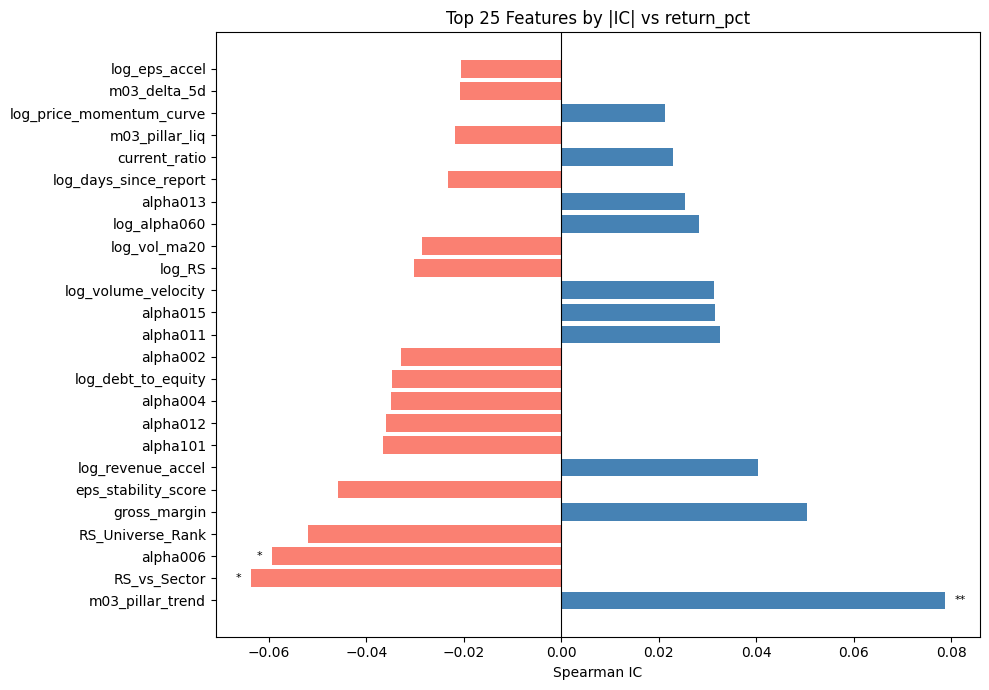

In [78]:
top_n = 25
ic_top = ic_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if v > 0 else 'salmon' for v in ic_top['IC']]
bars = ax.barh(ic_top['feature'], ic_top['IC'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Spearman IC")
ax.set_title(f"Top {top_n} Features by |IC| vs {target}")

# Significance markers
for i, row in enumerate(ic_top.itertuples()):
    marker = '***' if row.p_value < 0.001 else '**' if row.p_value < 0.01 else '*' if row.p_value < 0.05 else ''
    if marker:
        ax.text(row.IC + (0.002 if row.IC > 0 else -0.002), i, marker, 
                va='center', ha='left' if row.IC > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()


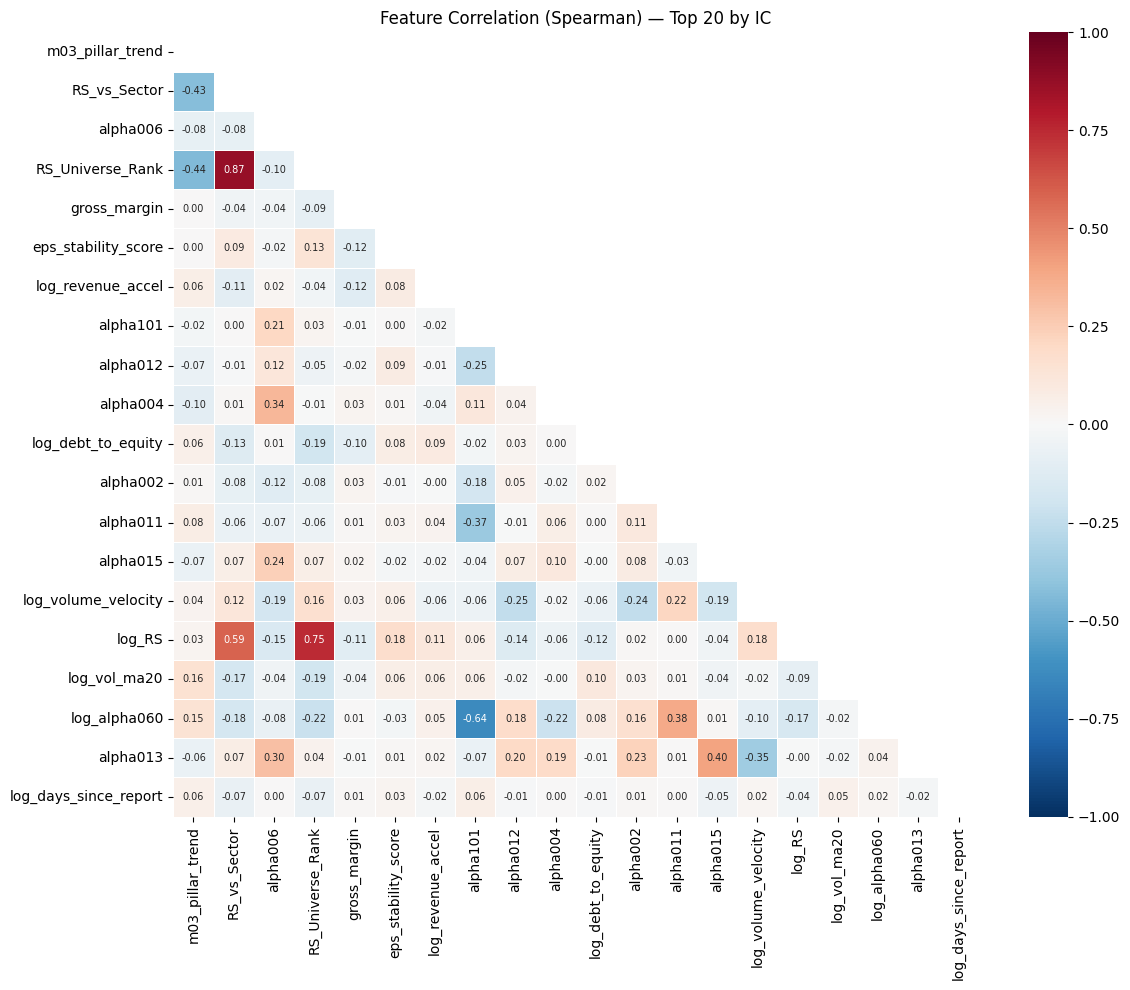

In [79]:
top_feats = ic_df.head(20)['feature'].tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_train[top_feats].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title("Feature Correlation (Spearman) — Top 20 by IC")
plt.tight_layout()
plt.show()


In [80]:
# Simple selection: high IC + low inter-correlation
IC_THRESHOLD = 0.03
CORR_THRESHOLD = 0.80

# Step 1: IC filter
ic_pass = ic_df[ic_df['IC'].abs() >= IC_THRESHOLD]['feature'].tolist()
print(f"IC filter ({IC_THRESHOLD}): {len(ic_pass)} features pass")

# Step 2: Greedy correlation drop
selected = []
corr_matrix = df_train[ic_pass].corr(method='spearman').abs()

for feat in ic_pass:  # already sorted by |IC| descending
    if not selected:
        selected.append(feat)
        continue
    max_corr_with_selected = corr_matrix.loc[feat, selected].max()
    if max_corr_with_selected < CORR_THRESHOLD:
        selected.append(feat)

print(f"After correlation filter ({CORR_THRESHOLD}): {len(selected)} features")
print(f"Selected: {selected}")


IC filter (0.03): 16 features pass
After correlation filter (0.8): 15 features
Selected: ['m03_pillar_trend', 'RS_vs_Sector', 'alpha006', 'gross_margin', 'eps_stability_score', 'log_revenue_accel', 'alpha101', 'alpha012', 'alpha004', 'log_debt_to_equity', 'alpha002', 'alpha011', 'alpha015', 'log_volume_velocity', 'log_RS']


---
## Section 6: M01 Training & Walk-Forward Evaluation
TimeSeriesSplit cross-validation: train on past, score on future.


In [81]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

SELECTED_FEATURES = selected  # from cell above, or override:
# SELECTED_FEATURES = available  # use all available M01 features

# Build log-hybrid target (compress tails, sign-preserving)
df_train['log_hybrid'] = np.sign(df_train[target]) * np.log1p(np.abs(df_train[target]))

# Encode categoricals
cat_cols = [c for c in CATEGORICAL_FEATURES if c in SELECTED_FEATURES]
for col in cat_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].fillna('Unknown').astype(str))

# Sort chronologically
df_model = df_train.sort_values('date').dropna(subset=SELECTED_FEATURES + ['log_hybrid'])

X = df_model[SELECTED_FEATURES].values
y = df_model['log_hybrid'].values
dates = pd.to_datetime(df_model['date'])

print(f"Training data: {X.shape}, target mean={y.mean():.4f}, std={y.std():.4f}")


Training data: (924, 15), target mean=0.0064, std=0.0643


In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

XGB_PARAMS = {
    'n_estimators': 300,
    'learning_rate': 0.03,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 5.0,
    'reg_lambda': 3.0,
    'random_state': 42,
    'n_jobs': -1
}

fold_metrics = []
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    preds = model.predict(X_val)
    oof_preds[val_idx] = preds
    
    # IC (Spearman)
    ic, pval = stats.spearmanr(preds, y_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    
    # Top decile edge
    val_df = pd.DataFrame({'pred': preds, 'actual': y_val})
    top10_actual = val_df.nlargest(max(1, int(len(val_df)*0.10)), 'pred')['actual'].mean()
    mean_actual = val_df['actual'].mean()
    edge = top10_actual - mean_actual
    
    fold_metrics.append({
        'fold': fold + 1,
        'n_train': len(train_idx),
        'n_val': len(val_idx),
        'IC': ic,
        'IC_pval': pval,
        'RMSE': rmse,
        'MAE': mae,
        'Top10_Edge': edge,
        'date_min': dates.iloc[val_idx].min().strftime('%Y-%m'),
        'date_max': dates.iloc[val_idx].max().strftime('%Y-%m')
    })
    
    print(f"Fold {fold+1}: IC={ic:.4f} (p={pval:.3f}), RMSE={rmse:.4f}, Edge={edge:.4f} | Val: {fold_metrics[-1]['date_min']} → {fold_metrics[-1]['date_max']}")

metrics_df = pd.DataFrame(fold_metrics)
print("\n=== Walk-Forward Summary ===")
print(metrics_df.to_string(index=False))


Fold 1: IC=nan (p=nan), RMSE=0.0654, Edge=-0.0022 | Val: 2021-01 → 2021-03
Fold 2: IC=nan (p=nan), RMSE=0.0515, Edge=-0.0072 | Val: 2021-03 → 2021-06
Fold 3: IC=nan (p=nan), RMSE=0.0626, Edge=-0.0038 | Val: 2021-06 → 2023-02
Fold 4: IC=nan (p=nan), RMSE=0.0661, Edge=0.0040 | Val: 2023-02 → 2024-06
Fold 5: IC=nan (p=nan), RMSE=0.0620, Edge=0.0337 | Val: 2024-06 → 2026-01

=== Walk-Forward Summary ===
 fold  n_train  n_val  IC  IC_pval     RMSE      MAE  Top10_Edge date_min date_max
    1      154    154 NaN      NaN 0.065381 0.046825   -0.002173  2021-01  2021-03
    2      308    154 NaN      NaN 0.051487 0.034259   -0.007176  2021-03  2021-06
    3      462    154 NaN      NaN 0.062632 0.038984   -0.003766  2021-06  2023-02
    4      616    154 NaN      NaN 0.066057 0.039952    0.003969  2023-02  2024-06
    5      770    154 NaN      NaN 0.061977 0.038982    0.033693  2024-06  2026-01


In [83]:
print("\n=== M01 Aggregate Performance ===")
summary = {
    'IC_mean':        metrics_df['IC'].mean(),
    'IC_std':         metrics_df['IC'].std(),
    'IC_Sharpe':      metrics_df['IC'].mean() / metrics_df['IC'].std(),
    'IC_positive_%':  (metrics_df['IC'] > 0).mean(),
    'RMSE_mean':      metrics_df['RMSE'].mean(),
    'MAE_mean':       metrics_df['MAE'].mean(),
    'Edge_mean':      metrics_df['Top10_Edge'].mean(),
    'Edge_Sharpe':    metrics_df['Top10_Edge'].mean() / metrics_df['Top10_Edge'].std(),
}
for k, v in summary.items():
    print(f"  {k:20s}: {v:.4f}")



=== M01 Aggregate Performance ===
  IC_mean             : nan
  IC_std              : nan
  IC_Sharpe           : nan
  IC_positive_%       : 0.0000
  RMSE_mean           : 0.0615
  MAE_mean            : 0.0398
  Edge_mean           : 0.0049
  Edge_Sharpe         : 0.2959


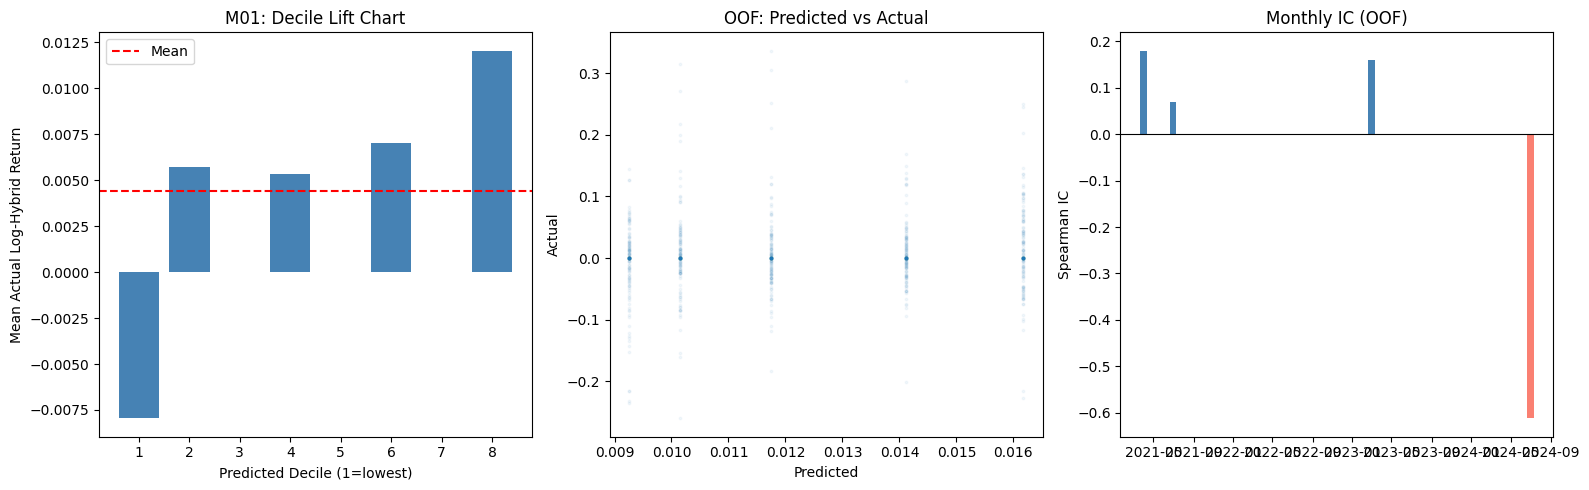

In [84]:
# OOF = out-of-fold predictions across all validation folds
oof_valid_mask = oof_preds != 0  # only filled folds

oof_df = pd.DataFrame({
    'pred': oof_preds[oof_valid_mask],
    'actual': y[oof_valid_mask],
    'date': dates.values[oof_valid_mask]
})

# Decile analysis
oof_df['pred_decile'] = pd.qcut(oof_df['pred'], q=10, labels=False, duplicates='drop')
decile_means = oof_df.groupby('pred_decile')['actual'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Decile lift chart
axes[0].bar(decile_means.index + 1, decile_means.values, color='steelblue')
axes[0].axhline(oof_df['actual'].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].set_xlabel("Predicted Decile (1=lowest)")
axes[0].set_ylabel("Mean Actual Log-Hybrid Return")
axes[0].set_title("M01: Decile Lift Chart")
axes[0].legend()

# Pred vs Actual scatter
axes[1].scatter(oof_df['pred'], oof_df['actual'], alpha=0.05, s=3)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("OOF: Predicted vs Actual")

# IC over time
monthly_ic = oof_df.resample('ME', on='date').apply(
    lambda g: stats.spearmanr(g['pred'], g['actual'])[0] if len(g) > 5 else np.nan
).dropna()
axes[2].bar(monthly_ic.index, monthly_ic.values, 
            color=['steelblue' if v > 0 else 'salmon' for v in monthly_ic.values],
            width=20)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title("Monthly IC (OOF)")
axes[2].set_ylabel("Spearman IC")

plt.tight_layout()
plt.show()


In [85]:
con.close()
print("✅ Connection closed.")

✅ Connection closed.
